# Netflix Data Analysis

This project explores the Netflix dataset to uncover insights about content distribution, genres, ratings, countries, directors, and trends in content additions over time. The analysis includes data cleaning, exploratory data analysis (EDA), and key business insights.

In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [3]:
netflix_df = pd.read_csv('netflix_titles.csv')
netflix_df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [4]:
netflix_df.describe().T

,count,mean,std,min,25%,50%,75%,max
release_year,8807.0,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0


In [5]:
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


####  

## Dataset Overview

The dataset contains information about Netflix Movies and TV Shows including title, type, director, cast, country, release year, rating, duration, and genres.

In [6]:
netflix_df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [7]:
netflix_df[netflix_df['rating'].isnull()].T

,5989,6827,7312,7537
show_id,s5990,s6828,s7313,s7538
type,Movie,TV Show,TV Show,Movie
title,13TH: A Conversation with Oprah Winfrey & Ava ...,Gargantia on the Verdurous Planet,Little Lunch,My Honor Was Loyalty
director,NaN,NaN,NaN,Alessandro Pepe
cast,"Oprah Winfrey, Ava DuVernay","Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...","Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...","Leone Frisa, Paolo Vaccarino, Francesco Miglio..."
country,NaN,Japan,Australia,Italy
date_added,"January 26, 2017","December 1, 2016","February 1, 2018","March 1, 2017"
release_year,2017,2013,2015,2015
rating,NaN,NaN,NaN,NaN
duration,37 min,1 Season,1 Season,115 min


In [8]:
netflix_df[netflix_df['duration'].isnull()].T

,5541,5794,5813
show_id,s5542,s5795,s5814
type,Movie,Movie,Movie
title,Louis C.K. 2017,Louis C.K.: Hilarious,Louis C.K.: Live at the Comedy Store
director,Louis C.K.,Louis C.K.,Louis C.K.
cast,Louis C.K.,Louis C.K.,Louis C.K.
country,United States,United States,United States
date_added,"April 4, 2017","September 16, 2016","August 15, 2016"
release_year,2017,2010,2015
rating,74 min,84 min,66 min
duration,NaN,NaN,NaN


####   

In [9]:
mask_df = netflix_df['duration'].isnull()
netflix_df.loc[mask_df,'duration'] = netflix_df.loc[mask_df, 'rating']
netflix_df.loc[mask_df, 'rating'] = np.nan

In [10]:
netflix_df['rating'] = netflix_df['rating'].fillna('Unknown')

In [11]:
netflix_df['director'] = netflix_df['director'].fillna('Unknown')

In [12]:
netflix_df['cast'] = netflix_df['cast'].fillna('Unknown')
netflix_df['country'] = netflix_df['country'].fillna('Unknown')

####   

In [13]:
netflix_df.dropna(subset = ['date_added'] , inplace = True )

In [14]:
netflix_df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [15]:
netflix_df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

##  

In [16]:
netflix_df ['date_added']= netflix_df['date_added'].str.strip()
netflix_df['date_added'] = pd.to_datetime(netflix_df['date_added'])

In [17]:
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8797 non-null   object        
 1   type          8797 non-null   object        
 2   title         8797 non-null   object        
 3   director      8797 non-null   object        
 4   cast          8797 non-null   object        
 5   country       8797 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8797 non-null   int64         
 8   rating        8797 non-null   object        
 9   duration      8797 non-null   object        
 10  listed_in     8797 non-null   object        
 11  description   8797 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 893.4+ KB


In [18]:
netflix_df.duplicated().sum()

np.int64(0)

## Data Cleaning

The following cleaning steps were performed:

- Handled missing values in Director, Cast, Country, Rating, and Duration columns.
- Corrected misplaced values between Rating and Duration columns.
- Converted Date Added column to datetime format.
- Created Year Added and Month Added columns for time-based analysis.
- Checked and handled duplicate records.
- Processed multi-value columns such as Country, Director, Cast, and Genres using split and explode techniques.

####  

# VISUALISATION

### Movies vs TV Shows

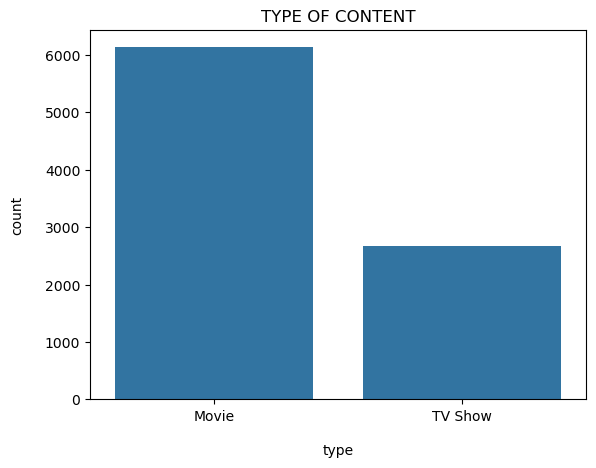

In [19]:
netflix_df['type'].value_counts()
sns.countplot(data = netflix_df, x = 'type');
plt.title('TYPE OF CONTENT');
plt.ylabel('count', labelpad=15);
plt.xlabel('type', labelpad=15);

#### Netflix’s catalog is dominated by Movies compared to TV Shows, indicating that the platform primarily focuses on movie content rather than series.

####  

### Movies and TV Shows Added by Year

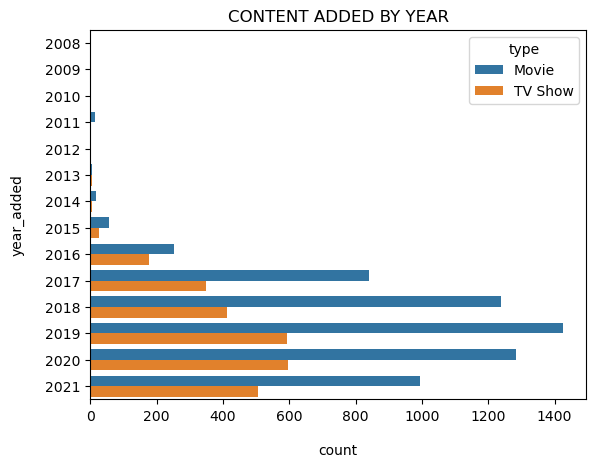

In [20]:
netflix_df['year_added'] = netflix_df['date_added'].dt.year
sns.countplot(data = netflix_df, y ='year_added', hue = 'type');
plt.title('CONTENT ADDED BY YEAR');
plt.xlabel('count', labelpad=15);
plt.ylabel('year_added', labelpad=15);

#### Netflix shows a sharp increase in content additions after 2015, reflecting its rapid global expansion and shift toward becoming a dominant streaming platform.

####  

### Movies and TV Shows Added by Month

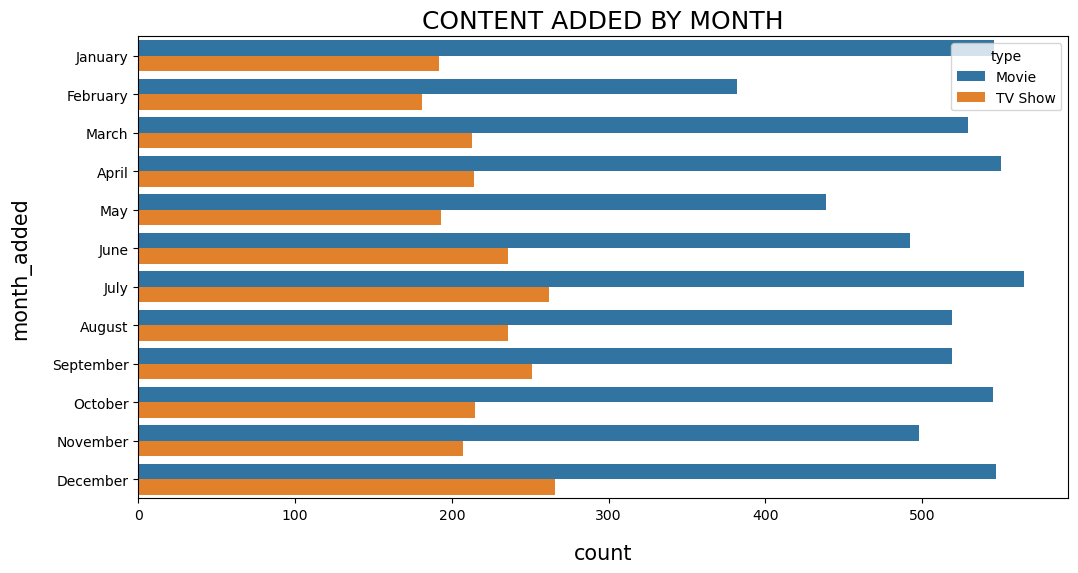

In [40]:
netflix_df['month_added'] = netflix_df['date_added'].dt.month_name();
plt.figure(figsize= (12,6));
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
];
sns.countplot(y= 'month_added' , data = netflix_df, hue = 'type' , order = month_order);
plt.xlabel('count', labelpad=15 , fontsize =15);
plt.ylabel('month_added', labelpad=15 , fontsize =15);
plt.title('CONTENT ADDED BY MONTH' , fontsize =18);

#### Content additions are fairly distributed across all months, with slight variations, suggesting Netflix does not strongly depend on seasonal release patterns.

####   

### Top Content Producing Countries

In [22]:
countries = netflix_df['country'].str.split(',').explode()
top_countries = countries.value_counts().head(10)
top_countries

country
United States     3205
India             1008
Unknown            830
United Kingdom     627
 United States     479
Canada             271
Japan              258
France             212
South Korea        211
 France            181
Name: count, dtype: int64

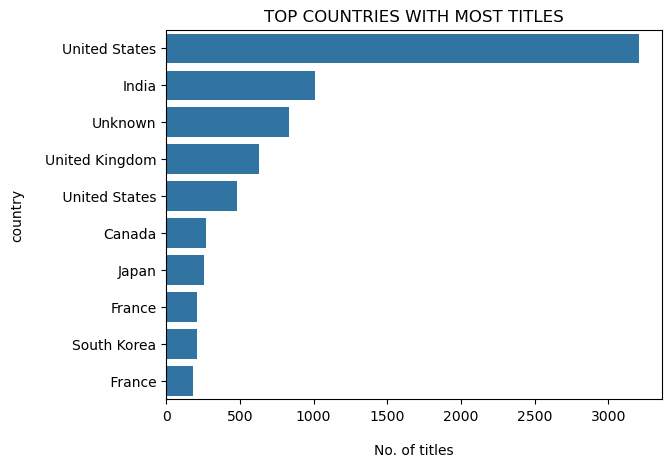

In [23]:
sns.barplot(x= top_countries.values,
            y= top_countries.index);
plt.title('TOP COUNTRIES WITH MOST TITLES');
plt.xlabel('No. of titles', labelpad=15);
plt.ylabel('country', labelpad=15);

#### The United States leads in content production on Netflix, followed by India and the United Kingdom, highlighting Netflix’s strong presence in both Western and Asian markets.

####  

### Distribution of Content Ratings

In [24]:
common_ratings = netflix_df['rating'].str.split(',').explode()
common_ratings = common_ratings[common_ratings != 'Unknown']
most_common_ratings = common_ratings.value_counts();
most_common_ratings

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

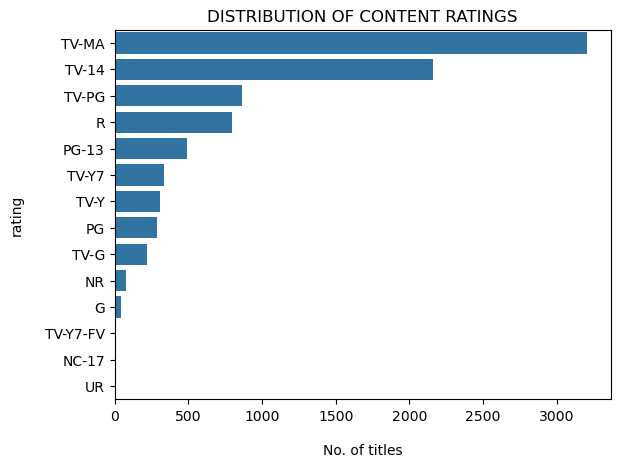

In [25]:
sns.barplot(x= most_common_ratings.values,
            y = most_common_ratings.index);
plt.title('DISTRIBUTION OF CONTENT RATINGS');
plt.xlabel('No. of titles', labelpad=15);
plt.ylabel('rating', labelpad=15);

#### TV-MA and TV-14 are the most frequent ratings, suggesting that Netflix primarily targets mature and teenage audiences rather than children.

####  

### Most Popular Genres on Netflix

In [26]:
genres = netflix_df['listed_in'].str.split(',').explode()
top_genres = genres.value_counts().head(10);
top_genres

listed_in
 International Movies     2624
Dramas                    1600
Comedies                  1210
Action & Adventure         859
Documentaries              829
 Dramas                    827
International TV Shows     773
 Independent Movies        736
 TV Dramas                 695
 Romantic Movies           613
Name: count, dtype: int64

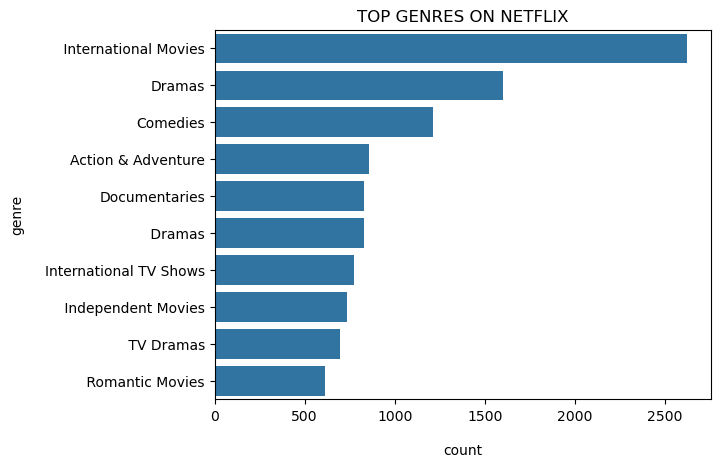

In [27]:
sns.barplot(x= top_genres.values,
            y= top_genres.index);
plt.title('TOP GENRES ON NETFLIX');
plt.xlabel('count', labelpad=15);
plt.ylabel('genre', labelpad=15);

#### International Movies, Dramas, and Comedies are the most common genres on Netflix, showing a strong emphasis on globally diverse and mainstream entertainment content.

####  

### Directors with the Highest Number of Titles

Missing values in the director column were replaced with "Unknown" during data cleaning. For director-specific analysis, the "Unknown" category was excluded to focus on identifiable directors.

In [28]:
directors = netflix_df['director'].str.split(',').explode();
directors = directors[directors != 'Unknown'];
top_directors = directors.value_counts().head(10);
top_directors

director
Rajiv Chilaka          22
Raúl Campos            18
 Jan Suter             18
Marcus Raboy           16
Suhas Kadav            16
Jay Karas              15
Cathy Garcia-Molina    13
Martin Scorsese        12
Jay Chapman            12
Youssef Chahine        12
Name: count, dtype: int64

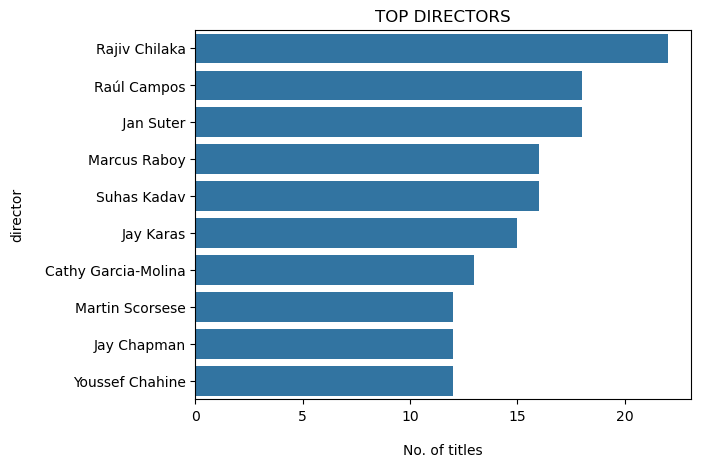

In [29]:
sns.barplot(x = top_directors.values,
            y = top_directors.index);
plt.title('TOP DIRECTORS');
plt.xlabel('No. of titles' ,labelpad= 15);
plt.ylabel('director' , labelpad =15);

#### A small group of directors contributes multiple titles, while most directors appear only once or twice, indicating a highly diverse pool of creators.

####  

### Most Frequently Appearing Cast Members

In [30]:
actors = netflix_df['cast'].str.split(',').explode();
actors = actors[actors != 'Unknown'];
top_actors = actors.value_counts().head(10);
top_actors

cast
 Anupam Kher         39
 Rupa Bhimani        31
 Takahiro Sakurai    30
 Julie Tejwani       28
 Om Puri             27
Shah Rukh Khan       26
 Rajesh Kava         26
 Paresh Rawal        25
 Yuki Kaji           25
 Boman Irani         25
Name: count, dtype: int64

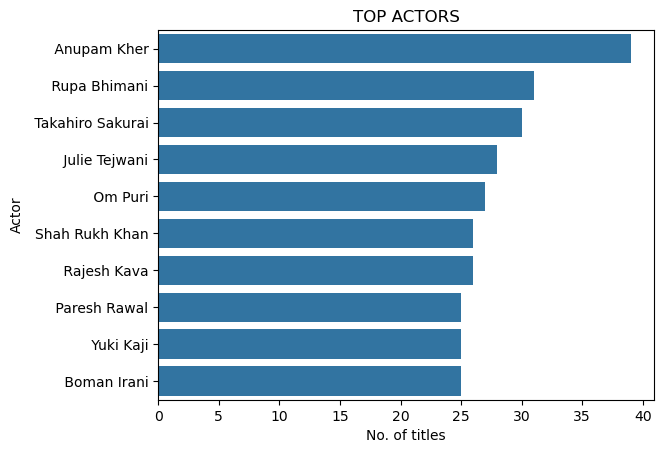

In [31]:
sns.barplot(x = top_actors.values,
            y = top_actors.index);
plt.title('TOP ACTORS');
plt.xlabel('No. of titles');
plt.ylabel('Actor');

#### A few actors appear repeatedly across multiple titles, suggesting frequent collaborations and popularity of certain performers on Netflix.

####  

## MOVIE DURATION ANALYSIS

In [32]:
movies = netflix_df[netflix_df['type'] == 'Movie'].copy()

movies['duration_min'] = (
    movies['duration']
    .str.replace('min', '', regex = False)
    .astype(int)
)

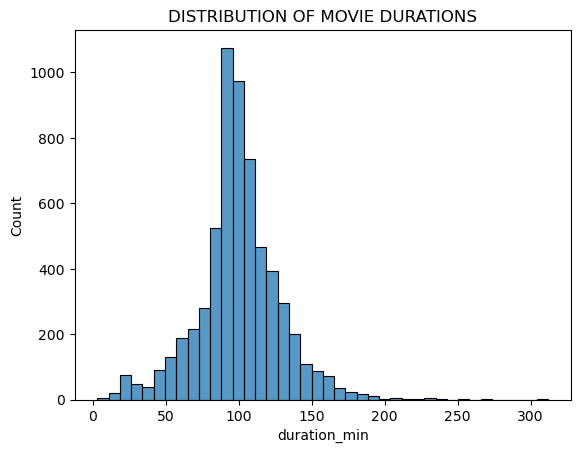

In [33]:
sns.histplot(movies['duration_min'], bins =40);
plt.title('DISTRIBUTION OF MOVIE DURATIONS');

#### Most Netflix movies fall within the 90–120 minute range, showing a preference for standard feature-length films.

####  

## TV SHOW SEASON ANALYSIS

In [34]:
shows = netflix_df[netflix_df['type'] == 'TV Show'].copy()

shows['seasons'] = (
    shows['duration']
    .str.replace(' Seasons', '', regex=False)
    .str.replace(' Season', '', regex=False)
    .astype(int)
)

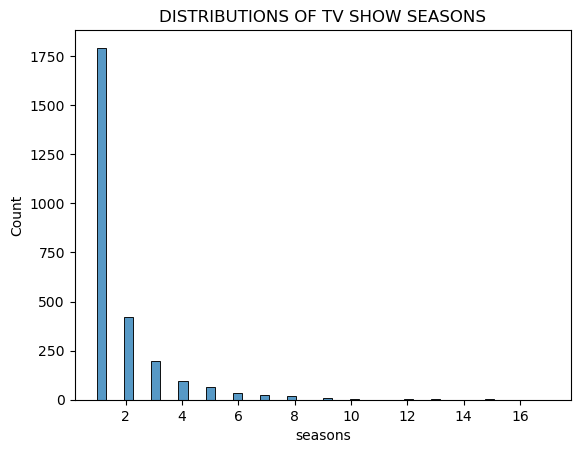

In [35]:
sns.histplot(shows['seasons'], bins =50);
plt.title('DISTRIBUTIONS OF TV SHOW SEASONS');

#### Most TV shows on Netflix have only 1–2 seasons, indicating that shorter series are more common on the platform.

#### 

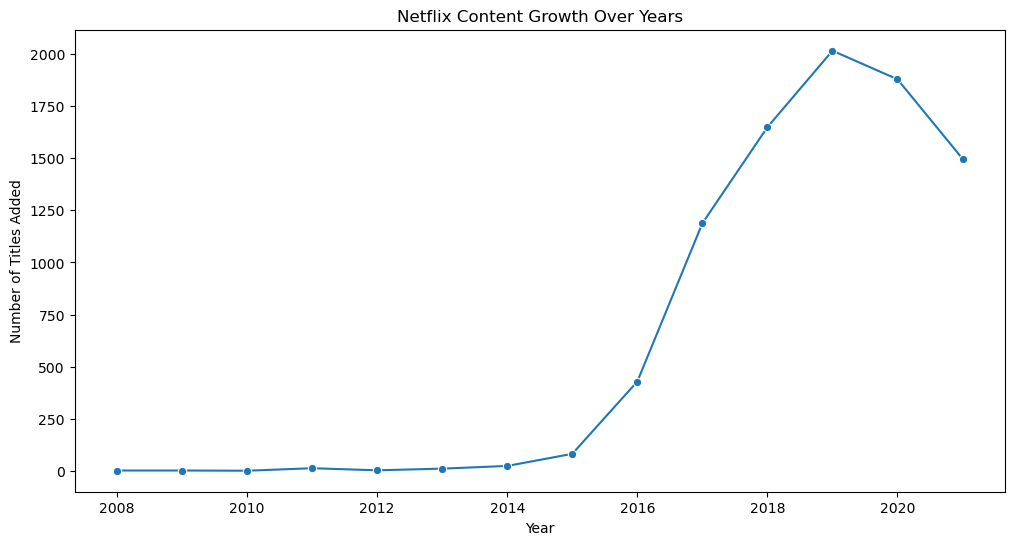

In [36]:
content_by_year = netflix_df ['year_added'].value_counts().sort_index()
plt.figure(figsize= (12,6))
sns.lineplot(
    x = content_by_year.index,
    y = content_by_year.values, 
    marker = 'o'
)
plt.title('Netflix Content Growth Over Years');
plt.xlabel('Year');
plt.ylabel('Number of Titles Added');

##### Netflix content additions increased significantly after 2015, showing rapid global expansion and investment in content acquisition and production.

###   

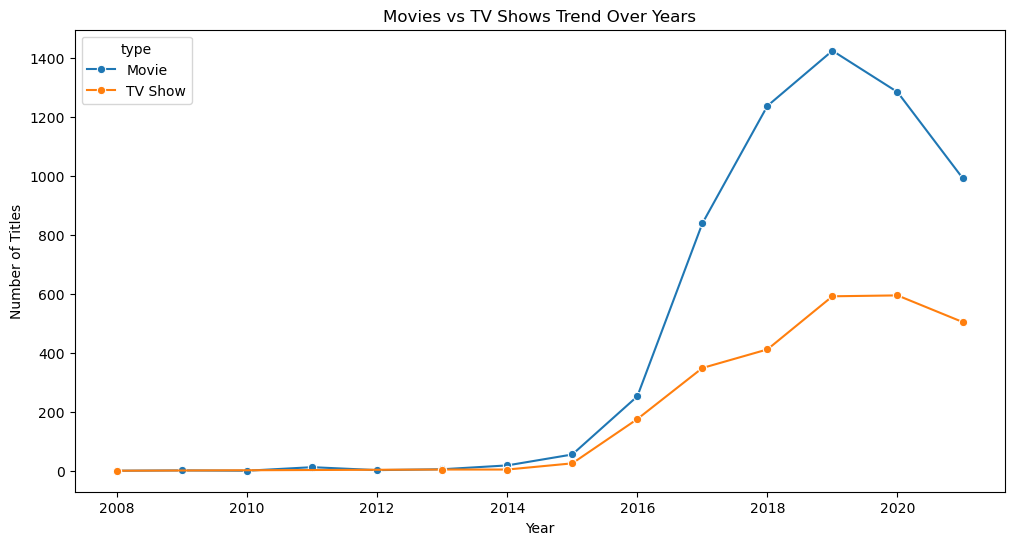

In [37]:
yearly_type = netflix_df.groupby(['year_added', 'type']).size().reset_index(name='count')

plt.figure(figsize=(12,6))

sns.lineplot(
    data=yearly_type,
    x='year_added',
    y='count',
    hue='type',
    marker='o'
);

plt.title('Movies vs TV Shows Trend Over Years');
plt.xlabel('Year');
plt.ylabel('Number of Titles');


#### Movies dominate Netflix’s catalog across all years, but TV Shows show a steady rise in later years, indicating increased focus on series-based content.

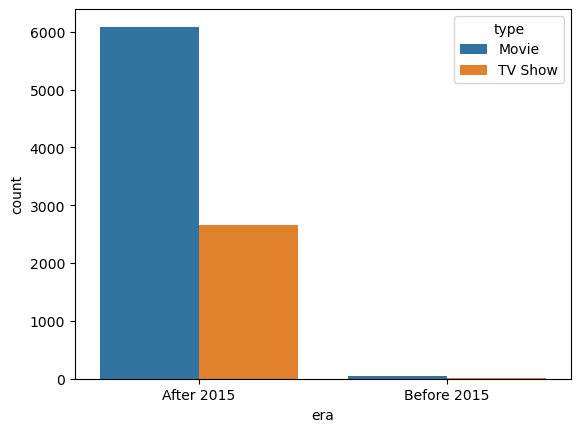

In [39]:
netflix_df['era'] = netflix_df['year_added'].apply(lambda x: 'Before 2015' if x < 2015 else 'After 2015');

sns.countplot(data=netflix_df, x='era', hue='type');

#### After 2015, Netflix dramatically expanded its content library, especially in TV Shows.

####  

# Conclusion

This Netflix Data Analysis project provides valuable insights into the platform’s content distribution and trends over time.

The analysis shows that Netflix’s library is heavily dominated by **Movies compared to TV Shows**, indicating a stronger focus on film-based content. The **United States, India, and the United Kingdom** are the leading contributors of content, highlighting Netflix’s global presence with strong contributions from both Western and Asian markets.

In terms of content classification, **International Movies, Dramas, and Comedies** are among the most common genres, reflecting Netflix’s diverse and global content strategy. The platform primarily targets **mature and teenage audiences**, as shown by the dominance of ratings like **TV-MA and TV-14**.

A clear growth trend is observed in content additions, with a significant rise after **2015**, indicating Netflix’s rapid expansion and shift toward becoming a global streaming giant. Most movies have a duration between **90–120 minutes**, while most TV shows consist of only **1–2 seasons**, suggesting a preference for short to medium-length content.

Overall, this analysis highlights how Netflix has evolved into a global entertainment platform with diverse content, strong international influence, and a clear shift toward digital streaming dominance in the post-2015 era.